# Craigslist Car Prediction

The dataset is saved in the Release section of Github as it is over 100MB and Github does not allow large files to be uploaded directly into the main branch.

In [1]:
pip install dill flaml[automl] numpy==1.24.4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 73.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 314.2/314.2 kB 23.9 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 1.24.4 which is incompatible.
treescope 0.1.9 requires numpy>=1.25.2, but you have numpy 1.24.4 which is incompatible.
jax 0.5.2 requires numpy>=1.25, but you have numpy 1.24.4 which is incompatible.
blosc2 3.3.1 requires numpy>=1.26, but you have numpy 1.24.4 which is incompatible.
jaxlib 0.5.1 requires numpy>=1.25, but you have numpy 1.24.4 which is incompatible.
t

Mounted at /content/drive
 First Five Rows of the Dataset:


,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN
3,7222270760,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaN
4,7210384030,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaN


 Dataset Shape: (426880, 26)

 Data Types and Missing Values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   url           426880 non-null  object 
 2   region        426880 non-null  object 
 3   region_url    426880 non-null  object 
 4   price         426880 non-null  int64  
 5   year          425675 non-null  float64
 6   manufacturer  409234 non-null  object 
 7   model         421603 non-null  object 
 8   condition     252776 non-null  object 
 9   cylinders     249202 non-null  object 
 10  fuel          423867 non-null  object 
 11  odometer      422480 non-null  float64
 12  title_status  418638 non-null  object 
 13  transmission  424324 non-null  object 
 14  VIN           265838 non-null  object 
 15  drive         296313 non-null  object 
 16  size          120519 non-null 

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
count,4.268800e+05,426880,426880,426880,4.268800e+05,425675.000000,409234,421603,252776,249202,423867,4.224800e+05,418638,424324,265838,296313,120519,334022,296677,426812,426810,0.0,426880,420331.000000,420331.000000,426812
unique,NaN,426880,404,413,NaN,NaN,42,29667,6,8,5,NaN,6,3,118264,3,4,13,12,241899,360911,NaN,51,NaN,NaN,381536
top,NaN,https://prescott.craigslist.org/cto/d/prescott...,columbus,https://spokane.craigslist.org,NaN,NaN,ford,f-150,good,6 cylinders,gas,NaN,clean,automatic,1FMJU1JT1HEA52352,4wd,full-size,sedan,white,https://images.craigslist.org/00N0N_1xMPvfxRAI...,35 VEHICLES PRICED UNDER $3000!!! BIG TIME! T...,NaN,ca,NaN,NaN,2021-04-23T22:13:05-0400
freq,NaN,1,3608,2988,NaN,NaN,70985,8009,121456,94169,356209,NaN,405117,336524,261,131904,63465,87056,79285,7357,231,NaN,50614,NaN,NaN,12
mean,7.311487e+09,NaN,NaN,NaN,7.519903e+04,2011.235191,NaN,NaN,NaN,NaN,NaN,9.804333e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,38.493940,-94.748599,NaN
std,4.473170e+06,NaN,NaN,NaN,1.218228e+07,9.452120,NaN,NaN,NaN,NaN,NaN,2.138815e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.841533,18.365462,NaN
min,7.207408e+09,NaN,NaN,NaN,0.000000e+00,1900.000000,NaN,NaN,NaN,NaN,NaN,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-84.122245,-159.827728,NaN
25%,7.308143e+09,NaN,NaN,NaN,5.900000e+03,2008.000000,NaN,NaN,NaN,NaN,NaN,3.770400e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.601900,-111.939847,NaN
50%,7.312621e+09,NaN,NaN,NaN,1.395000e+04,2013.000000,NaN,NaN,NaN,NaN,NaN,8.554800e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39.150100,-88.432600,NaN
75%,7.315254e+09,NaN,NaN,NaN,2.648575e+04,2017.000000,NaN,NaN,NaN,NaN,NaN,1.335425e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,42.398900,-80.832039,NaN


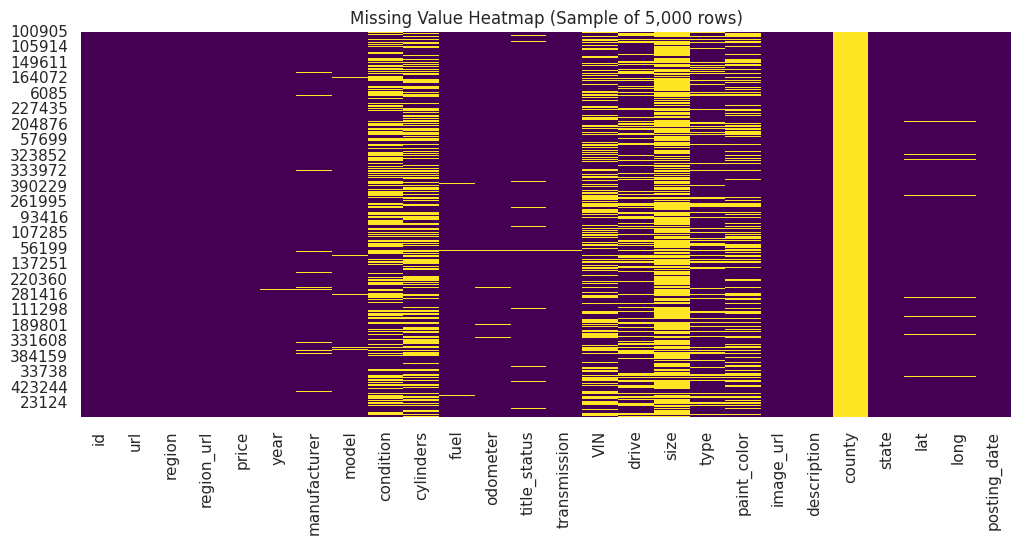


 Missing Values (%):
county          100.00
size             71.77
cylinders        41.62
condition        40.79
VIN              37.73
drive            30.59
paint_color      30.50
type             21.75
manufacturer      4.13
title_status      1.93
lat               1.53
long              1.53
model             1.24
odometer          1.03
fuel              0.71
transmission      0.60
year              0.28
description       0.02
image_url         0.02
posting_date      0.02
dtype: float64


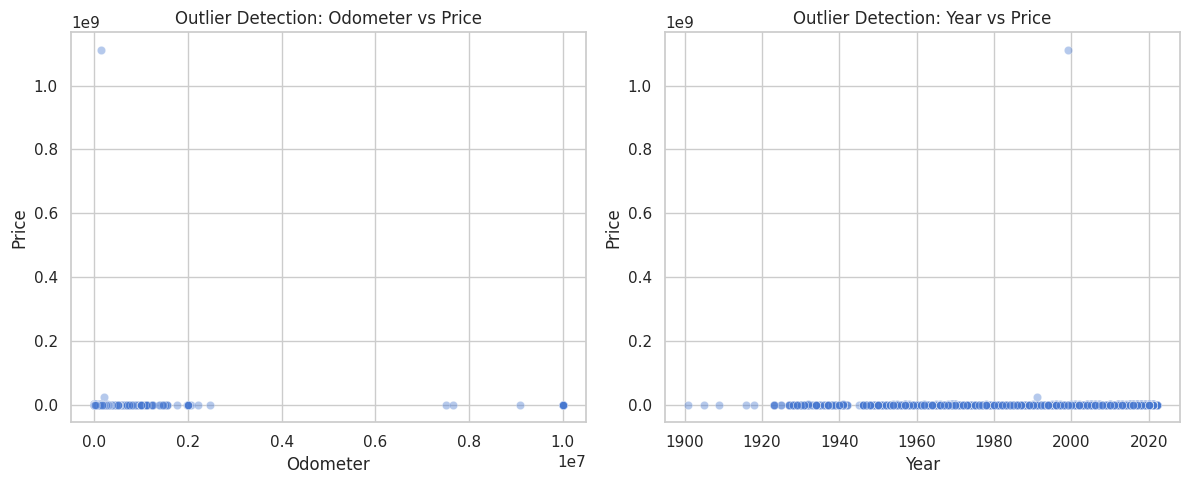

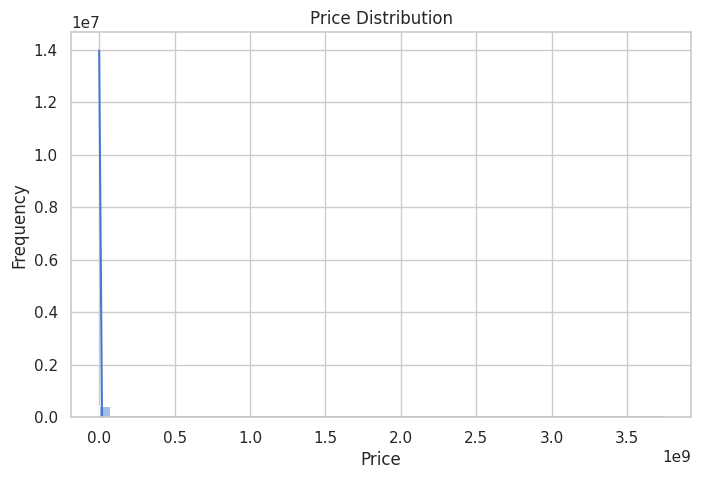


🔹 CONDITION Value Counts:

condition
NaN          174104
good         121456
excellent    101467
like new      21178
fair           6769
new            1305
salvage         601
Name: count, dtype: int64

🔹 FUEL Value Counts:

fuel
gas         356209
other        30728
diesel       30062
hybrid        5170
NaN           3013
electric      1698
Name: count, dtype: int64

🔹 TRANSMISSION Value Counts:

transmission
automatic    336524
other         62682
manual        25118
NaN            2556
Name: count, dtype: int64

🔹 TITLE_STATUS Value Counts:

title_status
clean         405117
NaN             8242
rebuilt         7219
salvage         3868
lien            1422
missing          814
parts only       198
Name: count, dtype: int64

🔹 DRIVE Value Counts:

drive
4wd    131904
NaN    130567
fwd    105517
rwd     58892
Name: count, dtype: int64

🔹 TYPE Value Counts:

type
NaN            92858
sedan          87056
SUV            77284
pickup         43510
truck          35279
other          2

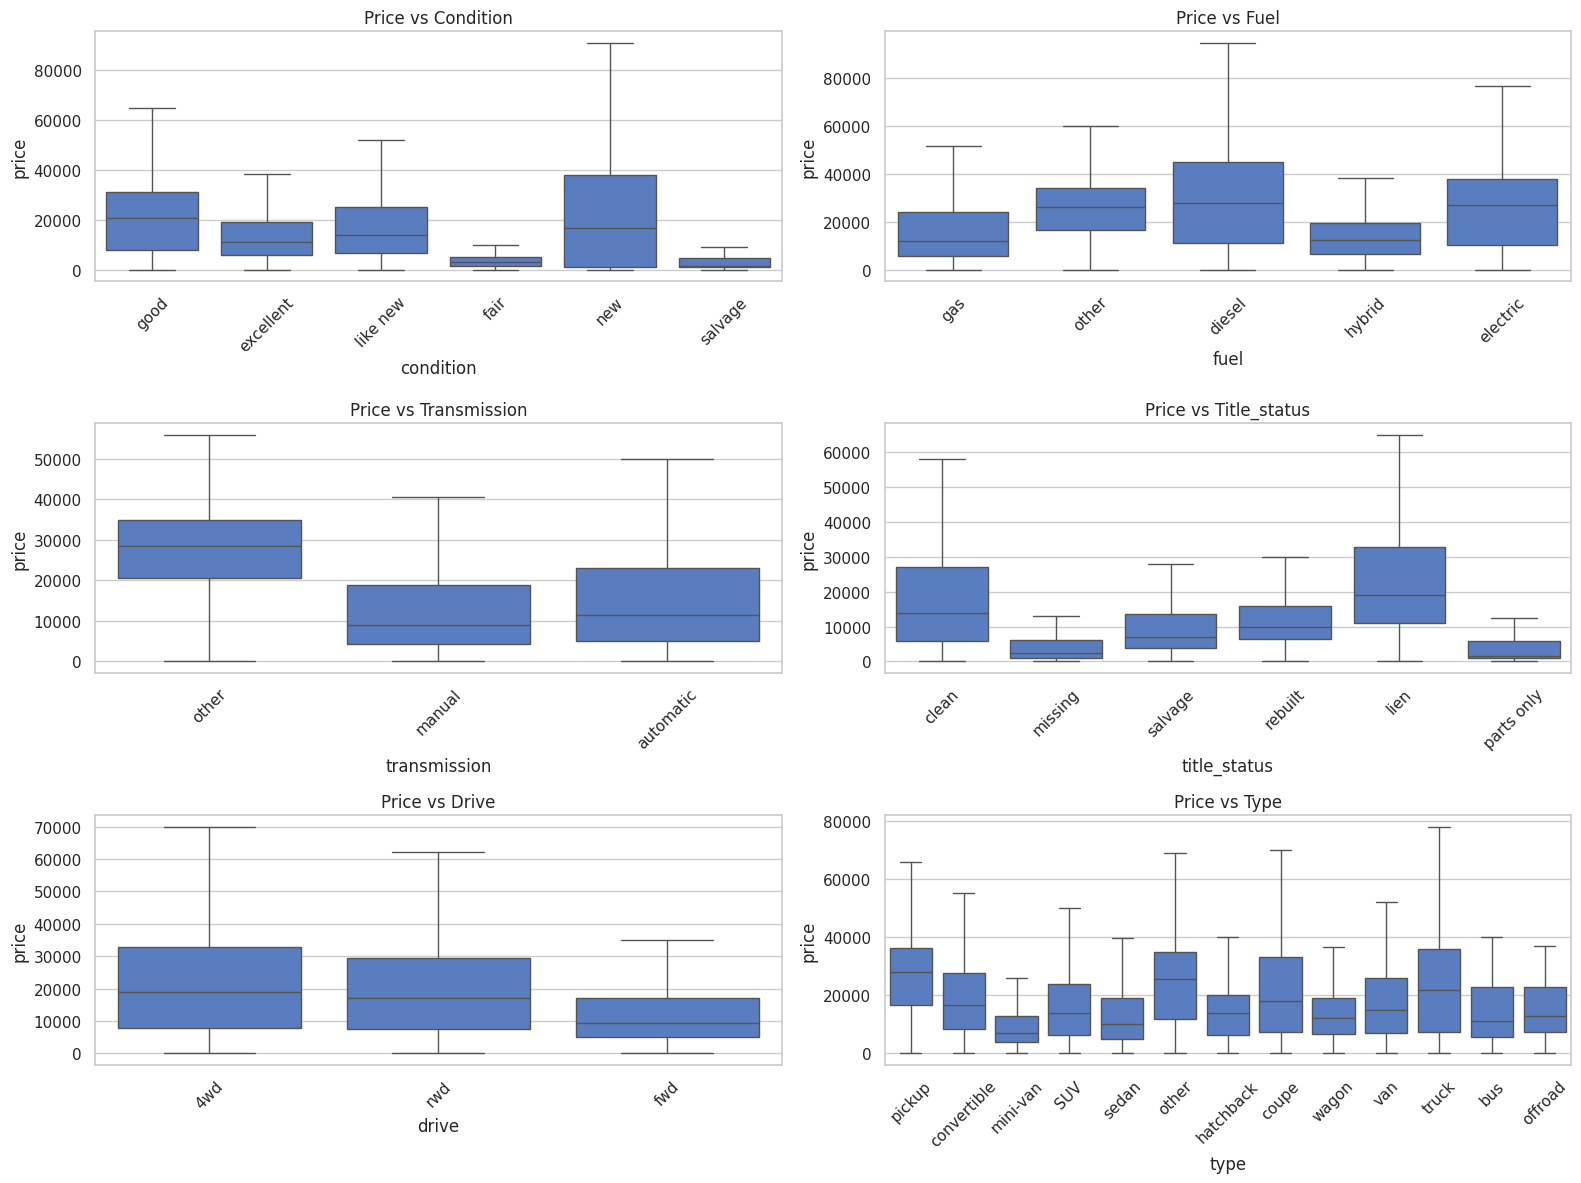

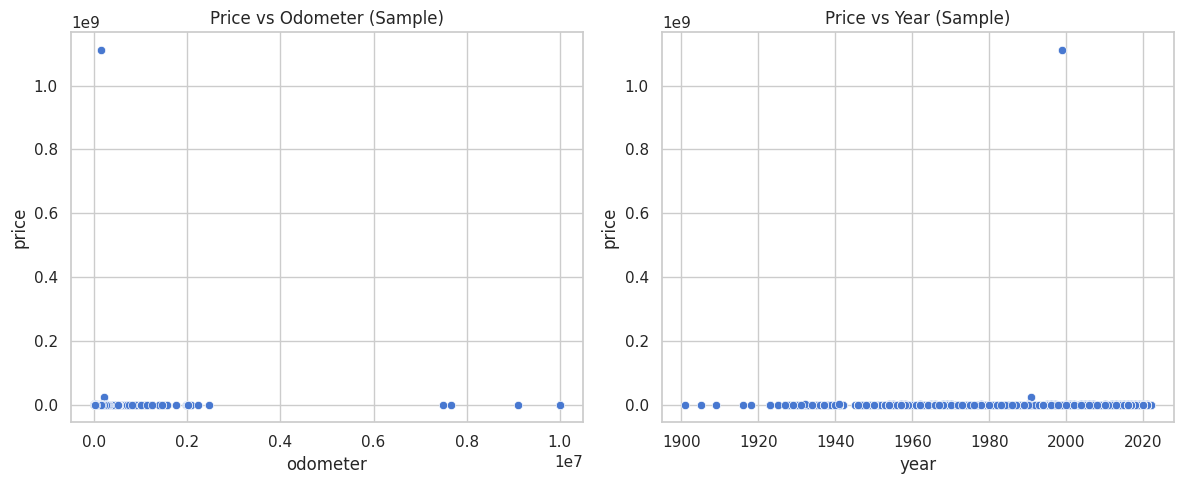

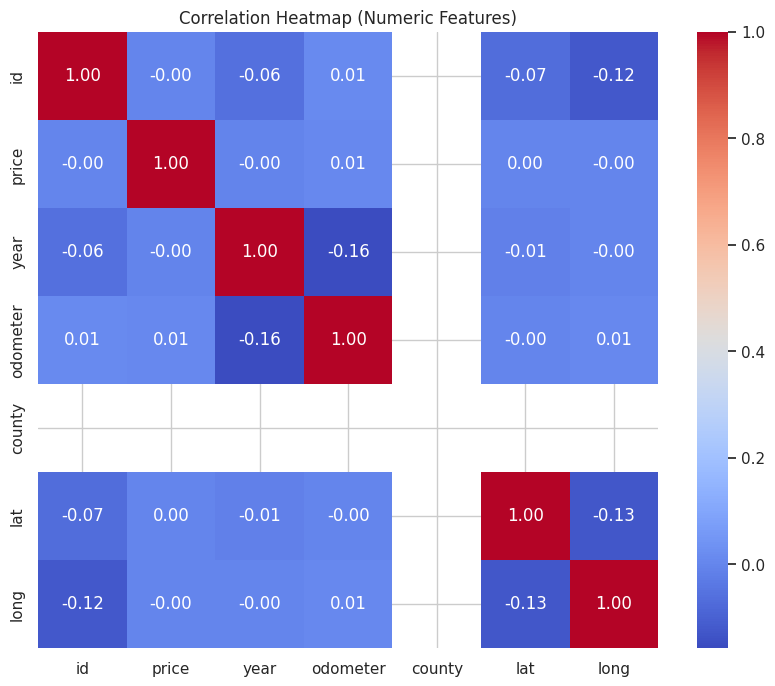


#########################################################################################################################################

Fitting 3 folds for each of 6 candidates, totalling 18 fits
[CV] END wrangle__continuous__impute__strategy=mean, wrangle__continuous__reddim__n_components=0; total time= 1.2min
[CV] END wrangle__continuous__impute__strategy=mean, wrangle__continuous__reddim__n_components=0; total time= 1.2min
[CV] END wrangle__continuous__impute__strategy=mean, wrangle__continuous__reddim__n_components=0; total time= 1.1min
[CV] END wrangle__continuous__impute__strategy=mean, wrangle__continuous__reddim__n_components=1; total time= 2.1min
[CV] END wrangle__continuous__impute__strategy=mean, wrangle__continuous__reddim__n_components=1; total time= 2.2min
[CV] END wrangle__continuous__impute__strategy=mean, wrangle__continuous__reddim__n_components=1; total time= 2.2min
[CV] END wrangle__continuous__impute__strategy=mean, wrangle__continuous__reddim__n_components=2; 

,wrangle__continuous__impute__strategy,wrangle__continuous__reddim__n_components,cv_score
grid_id,,,
2,mean,2,0.808588
5,median,2,0.808588
1,mean,1,0.773087
4,median,1,0.773087
0,mean,0,0.391766
3,median,0,0.391766


{'cv': 0.808588175158878, 'holdout': 0.8176208888135233}
{'MAE': 2685.196398194255, 'RMSE': 6376.832301073208, 'R²': 0.8176208888135233, 'Prediction Error Display': <sklearn.metrics._plot.regression.PredictionErrorDisplay object at 0x7eb3a0542f10>}


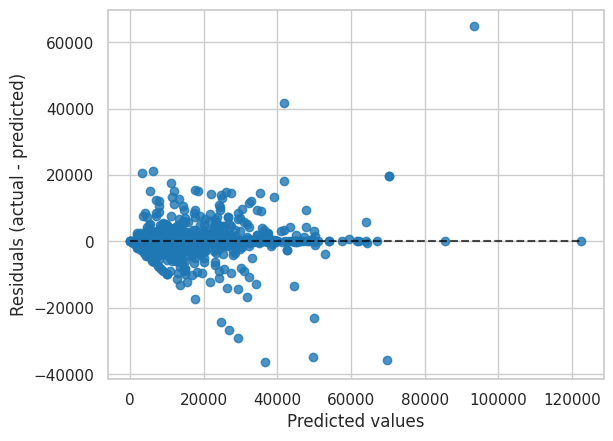

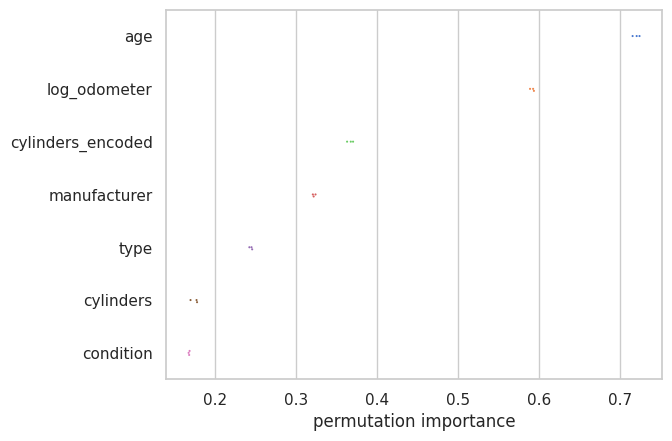

dump to /content/drive/MyDrive/2025sp_m5364_data_science_1/Datascience_Project/Craigslist_Car_Prediction/models/2025-05-02 18:59:51.272868.pkl
✅ Model saved to: /content/drive/MyDrive/2025sp_m5364_data_science_1/Datascience_Project/Craigslist_Car_Prediction/models/2025-05-02 18:59:51.272868.pkl

#########################################################################################################################################

Fitting 3 folds for each of 6 candidates, totalling 18 fits
[CV] END wrangle__continuous__impute__strategy=mean, wrangle__continuous__reddim__n_components=0; total time=   7.5s
[CV] END wrangle__continuous__impute__strategy=mean, wrangle__continuous__reddim__n_components=0; total time=  10.6s
[CV] END wrangle__continuous__impute__strategy=mean, wrangle__continuous__reddim__n_components=0; total time=   8.4s
[CV] END wrangle__continuous__impute__strategy=mean, wrangle__continuous__reddim__n_components=1; total time=   4.8s
[CV] END wrangle__continuous__impute

,wrangle__continuous__impute__strategy,wrangle__continuous__reddim__n_components,cv_score
grid_id,,,
4,median,1,0.358488
1,mean,1,0.343611
5,median,2,0.307349
2,mean,2,0.302175
3,median,0,0.155286
0,mean,0,0.092989


{'cv': 0.3584875073276477, 'holdout': 0.2388243849059314}
{'MAE': 9514.84225622104, 'RMSE': 13027.464008025083, 'R²': 0.2388243849059314, 'Prediction Error Display': <sklearn.metrics._plot.regression.PredictionErrorDisplay object at 0x7eb3a0737950>}


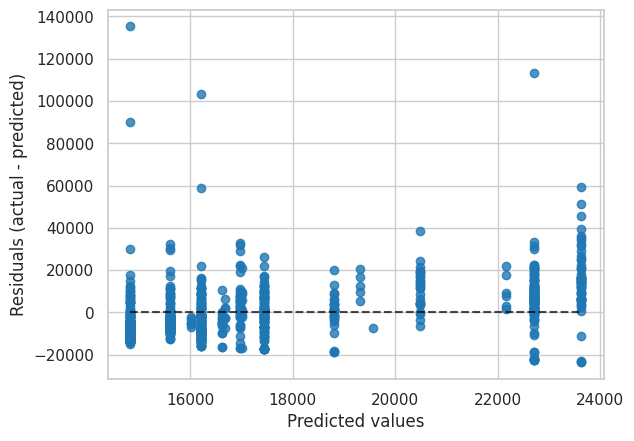

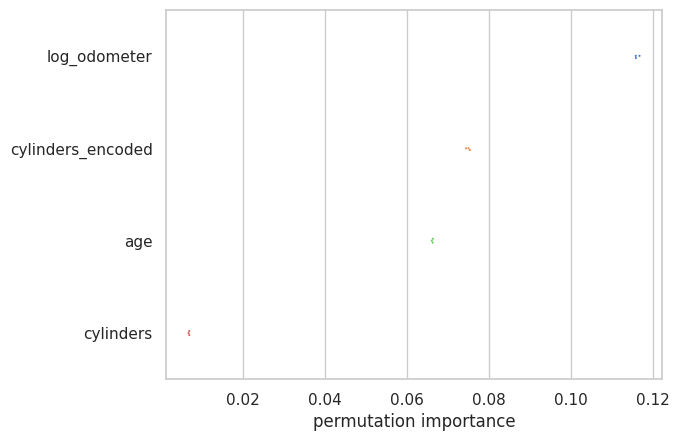

dump to /content/drive/MyDrive/2025sp_m5364_data_science_1/Datascience_Project/Craigslist_Car_Prediction/models/2025-05-02 19:58:51.365752.pkl
✅ Model saved to: /content/drive/MyDrive/2025sp_m5364_data_science_1/Datascience_Project/Craigslist_Car_Prediction/models/2025-05-02 19:58:51.365752.pkl


In [ ]:
# Import libraries
import pathlib, logging, dill, dataclasses, numpy as np, pandas as pd, sklearn as sk, matplotlib.pyplot as plt, seaborn as sns
from copy import deepcopy as copy
from datetime import datetime
from sklearn.impute import SimpleImputer #https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PowerTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error, PredictionErrorDisplay
from sklearn.inspection import permutation_importance
from flaml import AutoML
import warnings
warnings.filterwarnings('ignore')
sk.set_config(transform_output="pandas") #https://scikit-learn.org/stable/auto_examples/miscellaneous/plot_set_output.html
pd.set_option('display.max_columns', None)
logging.getLogger("flaml.tune.searcher.blendsearch").setLevel(logging.WARNING)

root = pathlib.Path('/Craigslist_Car_Prediction')
seed = 42

def disp(X, max_rows=3, precision=None, **props):
    """convenient display method"""
    props = {
        'text-align': 'center',
        'vertical-align': 'top',
        'border': '1px solid white',
        'width': 'auto',
        } | props
    fmt = {'precision': precision, 'hyperlinks': 'html'}
    try:
        display(
            pd.DataFrame(X)
            .head(max_rows)
            .style
            .format(**fmt)
            .format_index(**fmt, axis=0)
            .format_index(**fmt, axis=1)
            .highlight_null()
            .set_table_styles([{'selector':k, 'props':[*props.items()]} for k in ['th','td']])
        )
    except:
        print(X)

def rm(path, root=False):
    path = pathlib.Path(path)
    if path.is_file():
        path.unlink()
    elif path.is_dir():
        if root:
            shutil.rmtree(path)
        else:
            for p in path.iterdir():
                rm(p, True)

def mkdir(path):
    path = pathlib.Path(path)
    folder = path if path.suffix == '' else path.parent
    folder.mkdir(parents=True, exist_ok=True)
    return path

def reset(path):
    rm(path)
    return mkdir(path)

def dump(path, obj, **kwargs):
    path = reset(path)
    print(f'dump to {path}')
    if not isinstance(obj, pd.DataFrame):
        with open(path, 'wb') as f:
            return dill.dump(obj, f, **kwargs)
    elif path.suffix == '.parquet':
        obj.to_parquet(path, **kwargs)
    elif path.suffix == '.csv':
        obj.to_csv(path, **kwargs)
    else:
        raise Exception('path suffix must be .parquet or .csv if obj is a DataFrame')

def load(path, **kwargs):
    path = pathlib.Path(path)
    if path.suffix == '.parquet':
        return pd.read_parquet(path, **kwargs)
    elif path.suffix == '.csv':
        return pd.read_csv(path, **kwargs)
    else:
        with open(path, 'rb') as f:
            return dill.load(f, **kwargs)

#Read data
df = pd.read_csv(root/'used_cars.csv')

#Exploratory Data Analysis (EDA)

# Configuration
sns.set(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', None)

# Sample for heavy visualizations
sample_df = df[['price', 'odometer', 'year', 'condition']].dropna().sample(n=50000, random_state=42)

# Sneak Peek
print(" First Five Rows of the Dataset:")
display(df.head())

# Basic Structure of the Dataset
print(" Dataset Shape:", df.shape)
print("\n Data Types and Missing Values:")
df.info()

print("\n Summary Statistics:")
display(df.describe(include='all'))

# Missing Values Heatmap (sample)
plt.figure(figsize=(12, 5))
sns.heatmap(df.sample(n=5000, random_state=42).isna(), cbar=False, cmap='viridis')
plt.title('Missing Value Heatmap (Sample of 5,000 rows)')
plt.show()

# Missing Value Percentages
print("\n Missing Values (%):")
missing_pct = df.isna().mean().sort_values(ascending=False) * 100
print(missing_pct[missing_pct > 0].round(2))

plt.figure(figsize=(18, 5))

# Odometer vs Price
plt.subplot(1, 3, 1)
sns.scatterplot(x='odometer', y='price', data=sample_df, alpha=0.4)
plt.title('Outlier Detection: Odometer vs Price')
plt.xlabel('Odometer')
plt.ylabel('Price')

# Year vs Price
plt.subplot(1, 3, 2)
sns.scatterplot(x='year', y='price', data=sample_df, alpha=0.4)
plt.title('Outlier Detection: Year vs Price')
plt.xlabel('Year')
plt.ylabel('Price')

plt.tight_layout()
plt.show()

# Price Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

# Categorical Value Counts
categorical_cols = ['condition', 'fuel', 'transmission', 'title_status', 'drive', 'type', 'manufacturer']
for col in categorical_cols:
    print(f"\n🔹 {col.upper()} Value Counts:\n")
    print(df[col].value_counts(dropna=False))

# Price vs. Categorical Features (Boxplots, sample)
plt.figure(figsize=(16, 12))
for i, col in enumerate(categorical_cols[:6]):
    plt.subplot(3, 2, i+1)
    sns.boxplot(x=col, y='price', data=df.sample(n=50000, random_state=42), showfliers=False)
    plt.xticks(rotation=45)
    plt.title(f'Price vs {col.capitalize()}')

plt.tight_layout()
plt.show()

# Price vs. Numeric Features (Scatter, sample)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(x='odometer', y='price', data=sample_df)
plt.title('Price vs Odometer (Sample)')

plt.subplot(1, 2, 2)
sns.scatterplot(x='year', y='price', data=sample_df)
plt.title('Price vs Year (Sample)')

plt.tight_layout()
plt.show()

# Correlation Heatmap
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Heatmap (Numeric Features)')
plt.show()

# Feature Engineering

# Filter 'Odometer' outliers
df = df[(df['odometer'] <= 500000) & (df['odometer'] >= 100)].copy()
df['log_odometer'] = np.log1p(df['odometer'])

# Extract numeric value from 'cylinders'
df['cylinders'] = df['cylinders'].astype(str).str.extract(r'(\d+)')[0]
df['cylinders'] = pd.to_numeric(df['cylinders'], errors='coerce')
df = df[df['cylinders'].notna()].copy()
df['cylinders'] = df['cylinders'].astype(int)

# Group rare values and map to categories
common_cylinders = [4,5, 6, 8, 10]
df['cylinders'] = df['cylinders'].apply(lambda x: str(x) if x in common_cylinders else 'Other')
cylinder_order = {'4': 1, '5': 2, '6': 3, '8': 4, '10': 5, 'Other': 6}
df['cylinders_encoded'] = df['cylinders'].replace(cylinder_order)

# Ordinal encoding for condition
condition_order = {
   'new': 6,
   'like new': 5,
   'excellent': 4,
   'good': 3,
   'fair': 2,
   'salvage': 1 }
df['condition'] = df['condition'].replace(condition_order)
df['condition'] = pd.to_numeric(df['condition'], errors='coerce')

# Add derived features BEFORE train_test_split
current_year = datetime.now().year

# Calculate age safely (handle future years and zeros)
df = df.dropna(subset=['year']).copy()
df['age'] = (current_year - df['year']).clip(lower=1)
df['age'] = df['age'].astype(int)

df = df[(df['price'] > 0) & (df['price'] <= 400000)].copy()
# Drop rows with missing 'year' or 'odometer' and invalid years
X = df.dropna(subset=['year', 'odometer'])
X = X[X['year'] >= 1920].copy()

# Drop Target Variable
y = X['price']
X = X.drop(columns='price')

@dataclasses.dataclass
class CraigslistCarPrediction():
    wrangler: any
    learner: any
    param_grid: any
    scorer: any
    target: str = 'price'
    n_splits: int = 3
    refit_time: int = 60
    n_repeats: int = 3
    path: str = None

    def __post_init__(self):
        self.now = pd.Timestamp.now()
        self.path = mkdir(self.path if self.path is not None else root/f'models/{self.now}.pkl')

        # Make modeling & holdout sets
        self.X_modeling, self.X_holdout, self.y_modeling, self.y_holdout = train_test_split(X, y, test_size=0.2, random_state=seed)

        # Make estimator & grid
        self.learner.__sklearn_tags__ = getattr(sk.base, self.learner._estimator_type.capitalize()+'Mixin')().__sklearn_tags__
        self.estimator = Pipeline([('wrangle', self.wrangler), ('learn', self.learner)])
        self.grid = GridSearchCV(self.estimator, self.param_grid, cv=self.n_splits, scoring=self.scorer, refit=False, verbose=2)

    def train(self):
        self.grid.fit(self.X_modeling, self.y_modeling)
        # Retrain best estimator with larger time_budget and cross-validation if FLAML
        kwargs = {
            'time_budget': self.refit_time,
            'retrain_full': True,
            'eval_method': 'cv',
            'n_splits': self.n_splits,        }
        kwargs = {f'learn__{k}': v for k, v in kwargs.items() if k in self.learner.get_params()}

        # Refit best estimator with selected FLAML or regular learner
        self.estimator = self.estimator.set_params(**self.grid.best_params_).fit(self.X_modeling, self.y_modeling, **kwargs)

        # Prediction
        self.pred_modeling = self.estimator.predict(self.X_modeling)
        self.pred_holdout  = self.estimator.predict(self.X_holdout)

    def evaluate(self):
      #name of best algorithm
        self.algorithm = getattr(self.estimator['learn'], 'best_estimator', str(self.estimator['learn']).split('(')[0])
        disp(self.algorithm)

        # Gridsearchcv results
        self.grid.cv_df = pd.DataFrame(self.grid.cv_results_['params']).assign(cv_score=self.grid.cv_results_['mean_test_score']).sort_values('cv_score', ascending=False).rename_axis(index='grid_id')
        disp(self.grid.cv_df, None)

        # Best estimator's scores
        self.scores = {'cv':self.grid.best_score_, 'holdout':self.scorer(self.estimator, self.X_holdout, self.y_holdout)}
        disp(self.scores)

      # Reports
        self.regression_metrics = {
          'MAE': mean_absolute_error(self.y_holdout, self.pred_holdout),
          'RMSE': np.sqrt(mean_squared_error(self.y_holdout, self.pred_holdout)),
          'R²': r2_score(self.y_holdout, self.pred_holdout),
          'Prediction Error Display': PredictionErrorDisplay.from_predictions(self.y_holdout, self.pred_holdout)}

        disp(self.regression_metrics)
        plt.show()

        #feature importance (permutation)
        imp = permutation_importance(
            self.estimator,
            self.X_modeling,
            self.y_modeling,
            n_repeats=self.n_repeats,
            random_state=seed)
        self.importances = pd.DataFrame(imp.importances.T, columns=self.X_modeling.columns)
        mu = self.importances.mean().sort_values(ascending=False)
        sns.swarmplot(self.importances[mu[mu>0].index], orient='h', size=1.5)
        plt.xlabel('permutation importance')
        plt.show()

    def run(self):
        print('\n#########################################################################################################################################\n')
        self.train()
        self.evaluate()
        dump(self.path, self)
        print(f"✅ Model saved to: {self.path}")

models = []

# Fit into Pipeline
wrangler = ColumnTransformer((
            ('continuous', Pipeline((
            ('impute', SimpleImputer()),
            ('scale', StandardScaler()),
            ('reddim', PCA()),
        )),
        (
            'age',
            'log_odometer',

        )),
            ('ordinal', 'passthrough', ['cylinders_encoded', 'condition']),

            ('nominal', Pipeline((
            ('impute', SimpleImputer(strategy='most_frequent')),
            ('encode', OneHotEncoder(sparse_output=False,handle_unknown='ignore')),
        )),
        (
            'manufacturer',
            'type',
            'cylinders',
            'condition',
        )),
      ),
      remainder='drop',
      verbose_feature_names_out=False,
      )

n_continuous_features = len(wrangler.transformers[0][-1])
param_grid = {
    'wrangle__continuous__reddim__n_components': np.arange(1+n_continuous_features),
    'wrangle__continuous__impute__strategy': ['mean','median'],
}

regression_scorer = make_scorer(r2_score, greater_is_better=True)

for learner in [
    RandomForestRegressor(random_state=seed),
    AutoML(time_budget=3, eval_method='holdout', retrain_full=False, task='regression', metric='mae', seed=seed, verbose=0)

]:

     obj = CraigslistCarPrediction(wrangler, learner, param_grid, scorer=make_scorer(r2_score), refit_time=60)
     obj.run()
     models.append(obj)
